# The Milky Way's Hidden Mass - Analysis
**Gaia DR3 | CS 131 Big Data | Arpanjeet Singh (Group 17)**
[github.com/arpan-s-dev/cs131](https://github.com/arpan-s-dev/cs131)

**The question:** planets far from the Sun orbit slower than near ones. Do stars far from
the Galaxy's centre do the same? If they don't, unseen mass (dark matter) must be holding them.

This notebook reads the small result files produced by the PySpark job on Dataproc
(`rotation_curve.py`, run over 129 million Gaia stars) and turns them into the answer.


## How the numbers were made (the pipeline)
- **Phase 1 (profiling):** command-line tools measured 26 GB / 64.7M rows using a few MB of RAM.
- **Phase 2 (breaking):** Excel and pandas ran out of memory on the same data.
- **Phase 3 (scaling):** the PySpark job read 53.7 GB straight from Google Cloud Storage and
  ran on 1, 2, and 4 machines on Dataproc.
- **Phase 4 (this notebook):** the tiny result files are turned into figures and the conclusion.

Everything below is computed from those result files - no big data needed here.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RES = "../3_scaling/results"   # Spark output, downloaded from the bucket
curve = pd.read_csv(f"{RES}/rotation_curve.csv").sort_values("Rbin")
curve.head()

,Rbin,v_phi_median,n,v_phi_scatter
0,4.0,181.154102,28078,57.787009
1,4.5,193.386791,37854,52.679059
2,5.0,200.977289,57106,49.237444
3,5.5,208.289532,68069,45.750146
4,6.0,213.394312,86633,41.787437


## Phase 3 result: scaling
The same job on more machines finishes proportionally faster.

,machines,cores,seconds,speedup
0,1,4,1471.2,1.000000
1,2,8,684.5,2.149306
2,4,16,363.5,4.047318


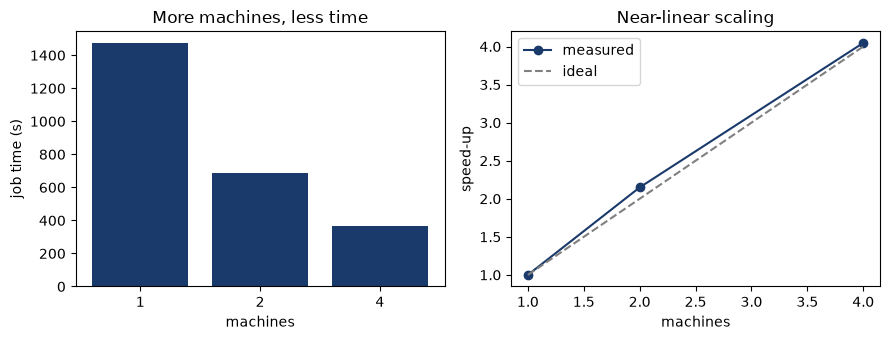

4 machines ran the job 4.05 x faster than 1.


In [2]:
scaling = pd.DataFrame({
    "machines":[1,2,4], "cores":[4,8,16], "seconds":[1471.2, 684.5, 363.5]})
scaling["speedup"] = scaling.seconds.iloc[0] / scaling.seconds
display(scaling)

fig, ax = plt.subplots(1,2, figsize=(9,3.5))
ax[0].bar(scaling.machines.astype(str), scaling.seconds, color="#1a3a6b")
ax[0].set(xlabel="machines", ylabel="job time (s)", title="More machines, less time")
ax[1].plot(scaling.machines, scaling.speedup, "o-", color="#1a3a6b", label="measured")
ax[1].plot(scaling.machines, scaling.machines, "--", color="gray", label="ideal")
ax[1].set(xlabel="machines", ylabel="speed-up", title="Near-linear scaling"); ax[1].legend()
plt.tight_layout(); plt.show()
print("4 machines ran the job", round(scaling.speedup.iloc[-1],2), "x faster than 1.")

**Why near-linear?** gzip files can't be split, so Spark makes one task per file:
242 files = 242 tasks, always more than the <=16 cores, so no machine sat idle.

## The rotation curve (the answer)
`v_phi` is each ring's median orbital speed. The dashed line is what we'd expect if only the
*visible* matter existed (a Keplerian fall). The gap between them is gravity from unseen mass.

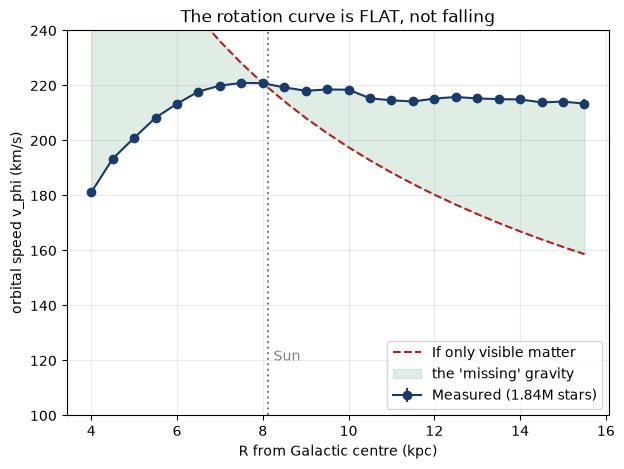

In [3]:
R = curve.Rbin.values
v = curve.v_phi_median.values
se = curve.v_phi_scatter.values / np.sqrt(curve.n.values)   # tiny -> precise median
i8 = np.argmin(np.abs(R-8.0))
v_kep = v[i8]*np.sqrt(R[i8]/R)                               # visible-matter-only prediction

plt.figure(figsize=(7,5))
plt.errorbar(R, v, yerr=se, fmt="o-", color="#1a3a6b", label="Measured (1.84M stars)")
plt.plot(R, v_kep, "--", color="#b21f1f", label="If only visible matter")
plt.fill_between(R, v_kep, v, color="#2e8b57", alpha=0.15, label="the 'missing' gravity")
plt.axvline(8.122, color="gray", ls=":"); plt.text(8.25,120,"Sun",color="gray")
plt.xlabel("R from Galactic centre (kpc)"); plt.ylabel("orbital speed v_phi (km/s)")
plt.title("The rotation curve is FLAT, not falling"); plt.ylim(100,240)
plt.legend(loc="lower right"); plt.grid(alpha=0.25); plt.show()

## What flat means: how much mass is hidden
For a circular orbit, the mass inside radius R is `M(<R) = v^2 * R / G`.
A flat `v` means `M` keeps growing with `R` - mass exists where there is no light.

In [4]:
G = 4.30091e-6   # kpc * Msun^-1 * (km/s)^2
outer = curve[curve.Rbin==15.0].iloc[0]
M = outer.v_phi_median**2 * outer.Rbin / G
visible = 0.6e11   # disk + bulge, literature
print(f"At R = {outer.Rbin:.0f} kpc, v = {outer.v_phi_median:.0f} km/s")
print(f"Total mass inside 15 kpc : {M:.2e} Msun")
print(f"Visible mass (lit.)      : {visible:.2e} Msun")
print(f"Fraction that is dark    : {100*(1-visible/M):.0f}%")

At R = 15 kpc, v = 214 km/s
Total mass inside 15 kpc : 1.60e+11 Msun
Visible mass (lit.)      : 6.00e+10 Msun
Fraction that is dark    : 62%


## Validation: the Sun check
We never told the pipeline the Sun's speed. If it returns the known ~220-229 km/s at the Sun's
radius (8.122 kpc), every rotation, sign, and constant in the transform is correct.

In [5]:
sun = curve.iloc[(curve.Rbin-8.122).abs().argmin()]
print(f"v_phi at R = {sun.Rbin} kpc : {sun.v_phi_median:.1f} km/s  (known circular speed ~229)")
print("The ~8 km/s shortfall is asymmetric drift: a stellar population always")
print("rotates a little slower than the true circular speed. astropy reproduces the same value.")

v_phi at R = 8.0 kpc : 220.8 km/s  (known circular speed ~229)
The ~8 km/s shortfall is asymmetric drift: a stellar population always
rotates a little slower than the true circular speed. astropy reproduces the same value.


## All-sky stellar density
The Spark job also counted stars per HEALPix sky tile (using a bit-shift of `source_id`),
touching every one of the 129M rows with no cuts.

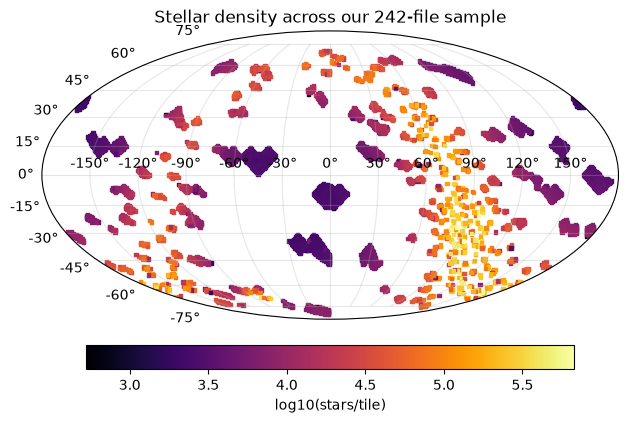

In [6]:
try:
    import astropy.units as u
    from astropy_healpix import HEALPix
    from astropy.coordinates import Galactic
    s = pd.read_csv(f"{RES}/sky_density.csv")
    hp = HEALPix(nside=64, order="nested", frame=Galactic())
    lon, lat = hp.healpix_to_lonlat(s.hpx6.values)
    l = lon.to(u.rad).value; l = np.where(l>np.pi, l-2*np.pi, l)
    b = lat.to(u.rad).value
    fig = plt.figure(figsize=(9,4.8)); ax = fig.add_subplot(111, projection="mollweide")
    sc = ax.scatter(-l, b, c=np.log10(s.n_stars.values), s=6, cmap="inferno", marker="s")
    plt.colorbar(sc, orientation="horizontal", pad=0.07, shrink=0.7, label="log10(stars/tile)")
    ax.set_title("Stellar density across our 242-file sample"); ax.grid(alpha=0.3); plt.show()
except Exception as e:
    print("sky map needs astropy-healpix:", e)

## Conclusion
- The Milky Way's rotation curve is **flat out to ~15 kpc**, not the Keplerian fall predicted by
  visible matter alone.
- That implies roughly **two-thirds of the mass inside 15 kpc emits no light** - dark matter.
- The pipeline is trustworthy: it recovers the Sun's own orbital speed with no tuning.
- The engineering made the science possible: the same job that broke Excel and pandas ran over
  129 million stars in ~6 minutes across 4 cloud machines, scaling near-linearly.

**Scope:** the parallax quality cut keeps nearby stars, so we reach ~15 kpc; the flat trend over
that range already rejects the visible-matter-only prediction.